In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

In [2]:
MIN_DEPTH_m = 3000.0
MIN_TILT_km = 5.0

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = tilt.add_region_labels(df, grid)
df = tilt.add_pv_gradient_terms(df, grid, core_mean=True)


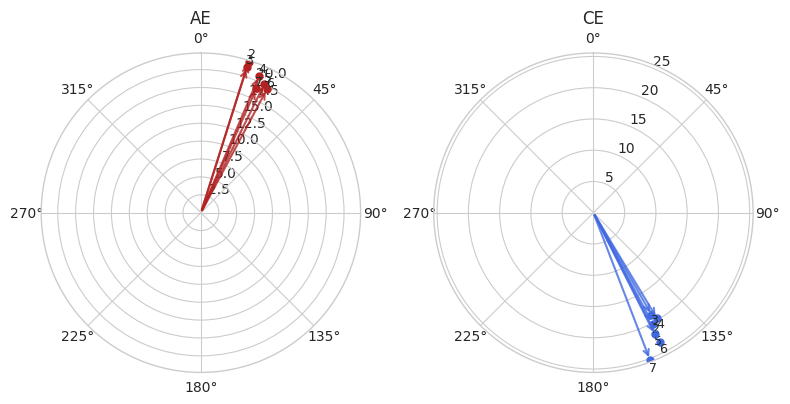

In [5]:
dom_facs = [2, 3, 4, 5, 6, 7]

vectors = {
    'AE': {'theta': [], 'r': []},
    'CE': {'theta': [], 'r': []},
}

for dom_fac in dom_facs:
    config = PVAlignmentConfig(
        dominance_factor=dom_fac,
        min_open_ocean_depth_m=MIN_DEPTH_m,
        min_tilt_distance_km=MIN_TILT_km,
    )

    d = add_pv_alignment_diagnostics(df, config)
    planetary = d[d.open_ocean_planetary & d.direction_valid].copy()

    for cyc in ['AE', 'CE']:
        sub = planetary[planetary.Cyc.eq(cyc)].dropna(
            subset=['TiltDir', 'TiltDis']
        )

        theta = np.deg2rad(sub.TiltDir)

        theta_mean = np.arctan2(
            np.mean(np.sin(theta)),
            np.mean(np.cos(theta))
        ) % (2*np.pi)

        r_mean = sub.TiltDis.mean()

        vectors[cyc]['theta'].append(theta_mean)
        vectors[cyc]['r'].append(r_mean)


fig, axs = plt.subplots(
    1, 2, figsize=(8, 4),
    subplot_kw={'projection': 'polar'}
)

for ax, cyc, color in zip(
    axs, ['AE', 'CE'], ['firebrick', 'royalblue']
):
    theta = np.array(vectors[cyc]['theta'])
    r = np.array(vectors[cyc]['r'])

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    for th, rr, dom_fac in zip(theta, r, dom_facs):

        # vector from origin
        ax.annotate(
            '',
            xy=(th, rr),
            xytext=(0, 0),
            arrowprops=dict(
                arrowstyle='->',
                color=color,
                lw=1.5,
                alpha=.8
            )
        )

        ax.scatter(th, rr, color=color, s=25)

        ax.text(
            th, rr * 1.05,
            str(dom_fac),
            ha='center',
            va='center',
            fontsize=9
        )

    ax.set_title(cyc)

plt.tight_layout()